In [1]:

import numpy as np
import polars as pl
from aeon.datasets.tsc_datasets import univariate

from autotsc import utils

In [2]:
df = (
    pl.scan_parquet("s3://tsc-glue/experiments/stacking_run_v1/*.parquet")
    .filter(pl.col("model") != "mixed-v2")
    .filter(pl.col("model") != "mixed-v3")
    .filter(pl.col("model") != "mixed-v4")  
    .filter(pl.col("model") != "mixed")
    .filter(pl.col("model") != "mixed-v4-ray-r-5")

).collect(engine="streaming")
df

/tmp/ipykernel_773267/1548207404.py:9: UserWarning: '(default_)region' not set; polars will try to get it from bucket

Set the region manually to silence this warning.
  ).collect(engine="streaming")


dataset,model,run,test_accuracy
str,str,i64,f64
"""ECG5000""","""mr-hydra""",200,0.946222
"""GestureMidAirD2""","""mr-hydra""",300,0.7
"""SemgHandMovementCh2""","""rdst""",600,0.706667
"""PLAID""","""quant""",300,0.947858
"""ECG5000""","""mixed-v4-ray-r-1""",200,0.948
…,…,…,…
"""ACSF1""","""mr-hydra""",500,0.9
"""BirdChicken""","""mixed-v4-ray""",300,0.9
"""NonInvasiveFetalECGThorax2""","""rstsf""",300,0.937405


In [3]:
from aeon.visualisation import plot_critical_difference

In [4]:
v = df.pivot(
    on="model", values="test_accuracy", index="dataset", aggregate_function="mean"
).drop_nulls()
methods = df["model"].unique().to_list()
v

dataset,mr-hydra,rdst,quant,mixed-v4-ray-r-1,rstsf,mixed-v4-ray
str,f64,f64,f64,f64,f64,f64
"""ECG5000""",0.946,0.944756,0.942978,0.948,0.944889,0.947111
"""PLAID""",0.941899,0.936685,0.945996,0.959032,0.89013,0.955307
"""Coffee""",1.0,0.992857,1.0,1.0,1.0,1.0
"""ECGFiveDays""",1.0,0.997871,0.997677,0.997677,0.998374,0.997677
"""ECG200""",0.915,0.901667,0.895714,0.92,0.9,0.92
…,…,…,…,…,…,…
"""SemgHandGenderCh2""",0.956,0.919667,0.951667,0.958333,0.972667,0.96
"""UWaveGestureLibraryY""",0.808208,0.764098,0.771133,0.810441,0.753071,0.811372
"""ItalyPowerDemand""",0.969485,0.944995,0.965986,0.961127,0.970036,0.966569


(<Figure size 600x250 with 1 Axes>, <Axes: >)

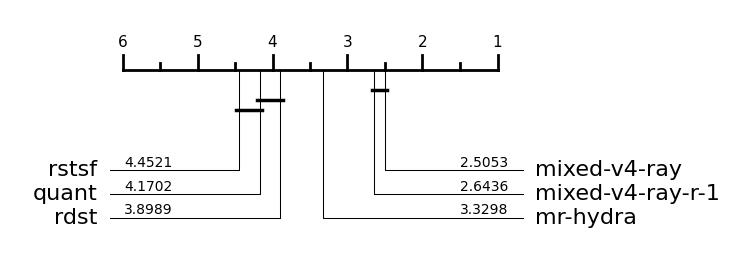

In [5]:
plot_critical_difference(v.select(methods).to_numpy(), methods)

In [6]:
def dataset_stats():

    stats = []
    for dataset in univariate:
        X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
        stats.append(
            {
                "dataset": dataset,
                "n_train": X_train.shape[0],
                "n_test": X_test.shape[0],
                "n_classes": len(np.unique(y_train)),
                "series_length": X_train.shape[2],
            }
        )
    return pl.DataFrame(stats)


stats = dataset_stats()

In [7]:
joined = v.join(stats, on="dataset").sort("n_train")
joined

dataset,mr-hydra,rdst,quant,mixed-v4-ray-r-1,rstsf,mixed-v4-ray,n_train,n_test,n_classes,series_length
str,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64
"""DiatomSizeReduction""",0.964052,0.933551,0.913399,0.962963,0.929739,0.964052,16,306,4,345
"""InsectEPGSmallTrain""",1.0,0.991968,1.0,1.0,1.0,1.0,17,249,3,601
"""DodgerLoopWeekend""",0.984127,0.984127,0.984127,0.984127,0.984127,0.984127,18,126,2,288
"""Fungi""",1.0,1.0,0.951613,1.0,0.910394,1.0,18,186,18,201
"""BeetleFly""",0.9,0.95,0.81,0.8,0.9,0.93,20,20,2,512
…,…,…,…,…,…,…,…,…,…,…
"""PhalangesOutlinesCorrect""",0.846154,0.808159,0.841259,0.851981,0.844988,0.854312,1800,858,2,80
"""FordA""",0.952273,0.949091,0.971364,0.986364,0.975505,0.98803,3601,1320,2,500
"""FordB""",0.830617,0.821728,0.800741,0.841975,0.821975,0.834979,3636,810,2,500


47


(<Figure size 600x250 with 1 Axes>, <Axes: >)

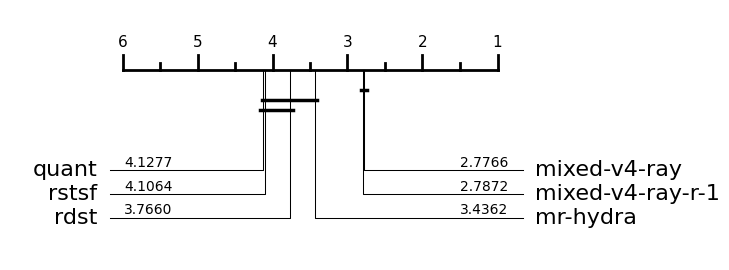

In [8]:
s_small = joined.filter(pl.col("n_train") < 200)
print(len(s_small))
plot_critical_difference(s_small.select(methods).to_numpy(), methods)

30


(<Figure size 600x250 with 1 Axes>, <Axes: >)

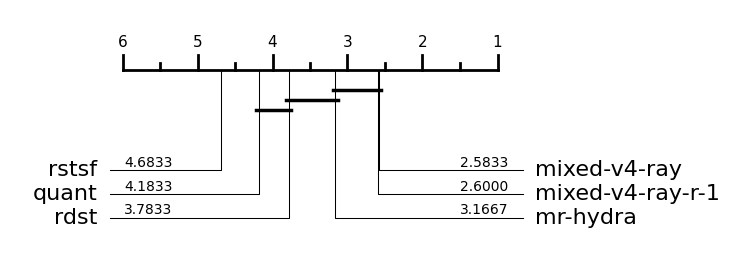

In [9]:
s_medium = joined.filter(pl.col("n_train") >= 200).filter(pl.col("n_train") < 600)
print(len(s_medium))
plot_critical_difference(s_medium.select(methods).to_numpy(), methods)

17


(<Figure size 600x250 with 1 Axes>, <Axes: >)

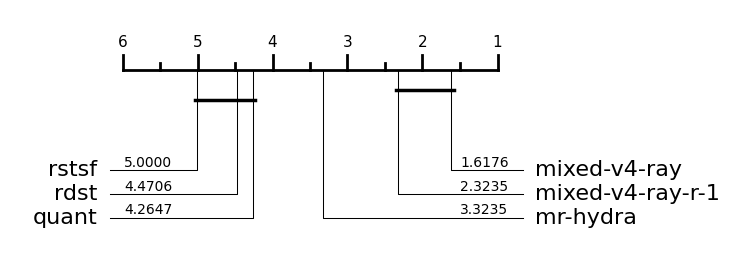

In [10]:
s_large = joined.filter(pl.col("n_train") >= 600)
print(len(s_large))
plot_critical_difference(s_large.select(methods).to_numpy(), methods)

In [11]:
s_large

dataset,mr-hydra,rdst,quant,mixed-v4-ray-r-1,rstsf,mixed-v4-ray,n_train,n_test,n_classes,series_length
str,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64
"""DistalPhalanxOutlineCorrect""",0.802899,0.772947,0.789251,0.775362,0.791063,0.80942,600,276,2,80
"""MiddlePhalanxOutlineCorrect""",0.852806,0.839175,0.848797,0.852234,0.845361,0.863688,600,291,2,80
"""ShapesAll""",0.927222,0.920667,0.873333,0.929583,0.856333,0.926667,600,600,60,512
"""Strawberry""",0.974131,0.976216,0.969369,0.975676,0.966667,0.975676,613,370,2,235
"""UWaveGestureLibraryX""",0.871301,0.855332,0.844547,0.877164,0.826121,0.878048,896,3582,8,315
…,…,…,…,…,…,…,…,…,…,…
"""PhalangesOutlinesCorrect""",0.846154,0.808159,0.841259,0.851981,0.844988,0.854312,1800,858,2,80
"""FordA""",0.952273,0.949091,0.971364,0.986364,0.975505,0.98803,3601,1320,2,500
"""FordB""",0.830617,0.821728,0.800741,0.841975,0.821975,0.834979,3636,810,2,500


In [12]:
import ray
ray.shutdown()